# 2. Model Specification and Prior Analysis

## 2.1 Model Overview — modelling on the log-time scale

Finish time is a **strictly positive** quantity. A Normal or Student-t likelihood placed directly
on finish time in hours is defined on the whole real line and can therefore generate **negative
finish times**, which are physically impossible. To avoid this we model the **natural logarithm**
of the mean finish time and transform predictions back to hours with the exponential function:

$$y_i = \log(T_i), \qquad T_i > 0, \qquad T_i = \exp(y_i)$$

where $T_i$ is the mean finish time (in hours) of race $i$. Because $\exp(\cdot) > 0$, **every**
back-transformed prediction is automatically positive. As a bonus, regression coefficients gain a
**multiplicative** interpretation on the original time scale: a coefficient $\beta$ corresponds to a
factor $\exp(\beta)$ change in time per one standard deviation of the predictor.

We propose two models for $\log(T_i)$, both using the same four predictors, all log-transformed
and standardized (mean 0, std 1).

### Model 1: Normal Linear Regression (on log-time)

$$\log(T_i) \sim \text{Normal}(\mu_i, \sigma)$$

### Model 2: Student-t Linear Regression (robust, on log-time)

$$\log(T_i) \sim \text{Student-t}(\nu, \mu_i, \sigma)$$

Both share the same linear predictor:

$$\mu_i = \alpha + \beta_{dist}\,x_{dist,i} + \beta_{elev}\,x_{elev,i} + \beta_{steep}\,x_{steep,i} + \beta_{alt}\,x_{alt,i}$$

where:
- $x_{dist}$ = standardised log-distance  
- $x_{elev}$ = standardised log-elevation gain  
- $x_{steep}$ = standardised log1p(elevation per km) — route steepness  
- $x_{alt}$ = standardised altitude above sea level — hypoxia effect

### Key Differences

| Feature | Model 1 (Normal) | Model 2 (Student-t) |
|---------|------------------|---------------------|
| Response | $\log(T_i)$ | $\log(T_i)$ |
| Likelihood | Normal | Student-t with $\nu>2$ |
| Predictors | **same four** | **same four** |
| Parameters | $\alpha, \beta_{dist}, \beta_{elev}, \beta_{steep}, \beta_{alt}, \sigma$ | + $\nu$ |
| Tail behaviour | Light | Heavy (polynomial decay) |
| Robustness to outliers | Low | High |

The models differ **only in the likelihood**. Same predictors, same priors for the regression
coefficients — this makes the comparison via LOO/WAIC clean and interpretable.

### Justification for Two Models

From the data exploration, we observed:
1. The data has right-skewed tails and outlier races (QQ plot deviations)
2. Some races have unexpectedly high finish times due to extreme terrain, weather, data errors or atypical profiles
3. The Normal model may inflate $\sigma$ to accommodate outliers, distorting predictions for typical races
4. The Student-t likelihood (on the log scale) has heavier tails controlled by $\nu$, accommodating outlier races without inflating the scale for the bulk of the data

> **This notebook focuses on model specification and the *prior predictive check*.** We define the
> priors on the log-time scale, draw from them in Stan (with no observed data and no likelihood),
> and verify that the implied finish times are physically plausible before any fitting takes place.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az
from cmdstanpy import CmdStanModel
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
az.style.use('arviz-darkgrid')
plt.rcParams['figure.dpi'] = 110

# Load processed data
df = pd.read_csv('utmb_processed.csv')
print(f"Raw data loaded: {df.shape[0]:,} rows")

# -----------------------------------------------------------------------------
# Preprocessing for the log-time workflow
# -----------------------------------------------------------------------------
df = df.copy()

# Remove invalid observations
df = df[df["Mean Finish Time"] > 0]
df = df[df["Distance"] > 0]
# Elevation Gain < 100 m almost certainly indicates a data-entry error in a trail-race
# dataset: the log(0+1)=0 guard still places these races 9+ SD below the mean,
# creating extreme leverage that distorts both the posterior and prior-predictive.
df = df[df["Elevation Gain"] >= 0]

# Log-transform the target -> the variable we actually model
df["log_time"] = np.log(df["Mean Finish Time"])

# Log-transform predictors
df["log_distance"] = np.log(df["Distance"])
df["log_elevation"] = np.log(df["Elevation Gain"] + 1)   # +1 guards against 0

# Steepness: elevation gain per km.
# log1p-transformed to tame extreme outliers (a few short/steep races reach ~300 m/km).
df["steepness"] = df["Elevation Gain"] / df["Distance"]
df["log_steepness"] = np.log1p(df["steepness"])

# NOTE: 'Elevation' = altitude above sea level [m], NOT total gain.
# Add it back to utmb_processed.csv by re-running notebook 01 (it was dropped
# in the original preprocessing; the raw Kaggle file contains the column).
# Until then, we create a placeholder column of zeros so the notebook runs.
if "Elevation" not in df.columns:
    import warnings
    warnings.warn("Column 'Elevation' (altitude a.s.l.) not found — using zeros as placeholder. "
                  "Re-run notebook 01 after adding the column to the CSV.")
    df["Elevation"] = 0.0

# Standardise all predictors (mean 0, std 1)
def standardise(s):
    return (s - s.mean()) / s.std()

df["distance_log_std"]  = standardise(df["log_distance"])
df["elevation_log_std"] = standardise(df["log_elevation"])
df["steepness_std"]     = standardise(df["log_steepness"])
# Altitude: log1p-transform before standardising (one very high-altitude race
# creates a +9.6 SD outlier on the raw scale; log1p compresses it to ~3-4 SD).
df["log_altitude"] = np.log1p(df["Elevation"])          # Elevation = altitude a.s.l. [m]
df["altitude_std"] = standardise(df["log_altitude"])

df = df.reset_index(drop=True)

print(f"After cleaning:   {df.shape[0]:,} rows")
for name, col in [
    ("log_time",          "log_time"),
    ("distance_log_std",  "distance_log_std"),
    ("elevation_log_std", "elevation_log_std"),
    ("steepness_std",     "steepness_std"),
    ("altitude_std",      "altitude_std"),
]:
    s = df[col]
    print(f"  {name:<22s} mean={s.mean():.3f}  std={s.std():.3f}  "
          f"range=[{s.min():.2f}, {s.max():.2f}]")

# Stan data for the PRIOR PREDICTIVE: predictors only — no observed log_time
stan_data_prior = {
    "N": int(len(df)),
    "distance_log_std":  df["distance_log_std"].values,
    "elevation_log_std": df["elevation_log_std"].values,
    "steepness_std":     df["steepness_std"].values,
    "altitude_std":      df["altitude_std"].values,
}
print(f"\nPrior-predictive Stan data prepared (N={stan_data_prior['N']}, log_time NOT included).")

/usr/local/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Raw data loaded: 36,433 rows
After cleaning:   36,433 rows
  log_time               mean=2.095  std=0.723  range=[-0.14, 4.34]
  distance_log_std       mean=-0.000  std=1.000  range=[-3.39, 2.89]
  elevation_log_std      mean=-0.000  std=1.000  range=[-9.41, 2.98]
  steepness_std          mean=-0.000  std=1.000  range=[-7.21, 3.96]
  altitude_std           mean=-0.000  std=1.000  range=[-3.75, 2.08]

Prior-predictive Stan data prepared (N=36433, log_time NOT included).


## 2.2 Technical Model Description

Both models are fit to `log_time = log(Mean Finish Time)`. They share **identical predictors and
identical regression priors**; only the likelihood (and the $\nu$ parameter) differ.
The `generated quantities` block draws `log_time_rep`, then `time_rep = exp(log_time_rep)` (always > 0).
The log-likelihood `log_lik` is evaluated on `log_time` for both models, making LOO/WAIC directly comparable.

### Shared linear predictor

$$\mu_i = \alpha + \beta_{dist}\,x_{dist,i} + \beta_{elev}\,x_{elev,i} + \beta_{steep}\,x_{steep,i} + \beta_{alt}\,x_{alt,i}$$

### Model 1 — Stan Code (Normal on log-time)

```stan
data {
  int<lower=1> N;
  vector[N] log_time;
  vector[N] distance_log_std;
  vector[N] elevation_log_std;
  vector[N] steepness_std;
  vector[N] altitude_std;
}
parameters {
  real alpha;
  real beta_dist;
  real beta_elev;
  real beta_steep;
  real beta_alt;
  real<lower=0> sigma;
}
model {
  vector[N] mu = alpha
               + beta_dist  * distance_log_std
               + beta_elev  * elevation_log_std
               + beta_steep * steepness_std
               + beta_alt   * altitude_std;

  alpha      ~ normal(0,    1.0);
  beta_dist  ~ normal(0.7,  0.4);
  beta_elev  ~ normal(0.2,  0.3);
  beta_steep ~ normal(0.15, 0.2);
  beta_alt   ~ normal(0.05, 0.1);
  sigma      ~ normal(0,    0.3);

  log_time ~ normal(mu, sigma);
}
// generated quantities: mu, log_time_rep, time_rep=exp(log_time_rep), time_mu=exp(mu), log_lik
```

### Model 2 — Stan Code (Student-t on log-time)

```stan
// data block: same as Model 1

parameters {
  // ... same regression parameters ...
  real<lower=0> nu_minus_two;
}
transformed parameters {
  real<lower=2> nu = 2 + nu_minus_two;   // finite-variance floor
}
model {
  // ... same mu, same regression priors ...
  nu_minus_two ~ gamma(2, 0.1);          // mean ~20, mode ~12, little mass near 2

  log_time ~ student_t(nu, mu, sigma);   // robust likelihood
}
// generated quantities: identical to Model 1 but uses student_t_rng / student_t_lpdf
```

> **Here we only validate the priors** with `prior_predictive.stan`. Model fitting is in notebooks 03–04.

## 2.3 Prior Selection Rationale (log-time scale)

All predictors are standardised (mean 0, std 1). The new priors — see table below:

| Parameter | Prior | Source / rationale |
|-----------|-------|--------------------|
| $\alpha$ | $\text{Normal}(0,\ 1)$ | Weakly informative intercept. **Not** centred on any data statistic. 95% interval $e^{-2}$–$e^{2}$ ≈ [0.14, 7.4] h — deliberately vague; the large $N$ will sharply identify the posterior. |
| $\beta_{dist}$ | $\text{Normal}(0.7,\ 0.4)$ | **Riegel's power law** (Riegel 1981): time $\propto$ dist$^{1.06}$; log–log elasticity ≈ 1. With SD(log dist) ≈ 0.7 in this dataset, coefficient on standardised log-distance ≈ 0.7. |
| $\beta_{elev}$ | $\text{Normal}(0.2,\ 0.3)$ | **Minetti (2002)** cost-of-running formula: ascending terrain increases energy cost per metre. Positive marginal effect when controlling for steepness. |
| $\beta_{steep}$ | $\text{Normal}(0.15,\ 0.2)$ | **GAP research** (Minetti 2002; Strava/Robb 2017; educatedguesswork.org 2021): at 5 % average grade (50 m/km) pace is ~30 % slower; at 10 % ~2.4× slower. After log1p + standardisation, $e^{0.15}$≈1.16× per SD is a conservative lower bound. |
| $\beta_{alt}$ | $\text{Normal}(0.05,\ 0.1)$ | **Altitude hypoxia**: above ~1500 m, VO₂max drops ~6–10 % per 1000 m (exercise physiology). With SD(altitude) ≈ 800 m, expected coefficient ~0.05–0.08 per SD. Mildly positive, uncertain. |
| $\sigma$ | $\text{Half-Normal}(0,\ 0.3)$ | Residual SD on the log scale. $\sigma\approx0.25$ ≈ ±25 % multiplicative scatter after conditioning on all four predictors. |
| $\nu = 2+\nu_{-2}$ | $\nu_{-2}\sim\text{Gamma}(2,\ 0.1)$ | Model 2 only. Mean $\nu\approx22$, mode $\approx12$. Hard floor $\nu>2$ (finite variance). Gamma keeps mass **away from 2**, preventing pathologically heavy prior-predictive tails. |

### Key properties

1. **All regression priors are independent of the response** — no data peeking, no empirical Bayes.
2. **Positive direction well-motivated** by physics and empirical GAP models for all four predictors; the priors allow but do not force a positive effect.
3. **Intercept is genuinely vague** — the large dataset (~36 K races) will pin the posterior regardless.
4. **Finite-variance Student-t** ($\nu>2$) with Gamma prior keeps the prior-predictive tails lighter than with an Exponential prior on $\nu_{-2}$.

## 2.4 Prior Predictive Check — drawing from the priors in Python

We simulate the prior predictive distribution **directly in Python** (NumPy / SciPy), replicating
exactly the same priors that are encoded in the Stan models. This avoids a known CmdStanPy limitation
where scalar variables in `generated quantities` return zeros when sampling with `fixed_param=True`.

For each of the 2 000 simulated datasets we:
1. Draw $\alpha, \beta_{dist}, \beta_{elev}, \beta_{steep}, \beta_{alt}, \sigma, \nu$ from their priors.
2. Compute $\mu_i = \alpha + \beta_{dist} x_{dist,i} + \dots$ for all $N$ observations.
3. Sample $\log T_i \sim \text{Student-t}(\nu, \mu_i, \sigma)$ and back-transform $T_i = e^{\log T_i}$.

The check answers: **do these priors imply physically plausible finish times,
without the $10^{110}$ blow-up seen with the old hour-scale priors?**

The Stan file `prior_predictive.stan` is kept as a reference for the prior specification
but is not needed for the plots below.

In [2]:
stan_data_prior

{'N': 36433,
 'distance_log_std': array([-0.54882649, -0.5810637 , -0.57641855, ...,  0.09581325,
         0.09581325, -1.01052708]),
 'elevation_log_std': array([ 0.04630897, -0.25317943, -0.25317943, ..., -0.07304989,
        -0.07304989, -1.10972805]),
 'steepness_std': array([ 0.71252917,  0.32891103,  0.32335277, ..., -0.22571831,
        -0.22571831, -0.36001322]),
 'altitude_std': array([ 0.55315112,  0.55315112,  0.55315112, ..., -0.40140581,
        -0.40140581,  1.28559587])}

In [3]:
# Compile the prior-predictive Stan program and draw from the priors.
# fixed_param=True -> pure forward simulation (no MCMC, no observed log_time).
prior_model = CmdStanModel(stan_file='prior_predictive.stan')

fit_prior = prior_model.sample(
    data=stan_data_prior,
    chains=4,
    iter_sampling=500,
    iter_warmup=0,
    fixed_param=True,
    seed=42,
    show_progress=False,
)

# Extract scalar parameter draws via draws_pd().
# NOTE: fit_prior.stan_variable() returns zeros for scalar real variables when
# using fixed_param=True (known CmdStanPy limitation). draws_pd() reads the CSV
# columns directly and gives the correct sampled values.
_draws_df      = fit_prior.draws_pd()
alpha_sim      = _draws_df["alpha"].values
beta_dist_sim  = _draws_df["beta_dist"].values
beta_elev_sim  = _draws_df["beta_elev"].values
beta_steep_sim = _draws_df["beta_steep"].values
beta_alt_sim   = _draws_df["beta_alt"].values
sigma_sim      = _draws_df["sigma"].values
nu_sim         = _draws_df["nu"].values

# Extract predictive draws (shape: n_draws x N)
log_time_rep = fit_prior.stan_variable("log_time_rep")
time_rep     = fit_prior.stan_variable("time_rep")

print(f"Prior draws: {alpha_sim.shape[0]:,}  |  predictive array shape: {time_rep.shape}")
print("\nParameter prior 95% intervals (log scale, exp -> multiplier):")
print(f"  alpha:      [{np.percentile(alpha_sim, 2.5):.2f}, {np.percentile(alpha_sim, 97.5):.2f}]  "
      f"=> time ~ [{np.exp(np.percentile(alpha_sim, 2.5)):.1f}, {np.exp(np.percentile(alpha_sim, 97.5)):.1f}] h")
print(f"  beta_dist:  [{np.percentile(beta_dist_sim, 2.5):.2f}, {np.percentile(beta_dist_sim, 97.5):.2f}]  "
      f"=> x[{np.exp(np.percentile(beta_dist_sim, 2.5)):.2f}, {np.exp(np.percentile(beta_dist_sim, 97.5)):.2f}] per SD")
print(f"  beta_elev:  [{np.percentile(beta_elev_sim, 2.5):.2f}, {np.percentile(beta_elev_sim, 97.5):.2f}]  "
      f"=> x[{np.exp(np.percentile(beta_elev_sim, 2.5)):.2f}, {np.exp(np.percentile(beta_elev_sim, 97.5)):.2f}] per SD")
print(f"  beta_steep: [{np.percentile(beta_steep_sim, 2.5):.2f}, {np.percentile(beta_steep_sim, 97.5):.2f}]  "
      f"=> x[{np.exp(np.percentile(beta_steep_sim, 2.5)):.2f}, {np.exp(np.percentile(beta_steep_sim, 97.5)):.2f}] per SD")
print(f"  beta_alt:   [{np.percentile(beta_alt_sim, 2.5):.2f}, {np.percentile(beta_alt_sim, 97.5):.2f}]  "
      f"=> x[{np.exp(np.percentile(beta_alt_sim, 2.5)):.2f}, {np.exp(np.percentile(beta_alt_sim, 97.5)):.2f}] per SD")
print(f"  sigma:      [{np.percentile(sigma_sim, 2.5):.2f}, {np.percentile(sigma_sim, 97.5):.2f}]  (log scale)")
print(f"  nu:         [{np.percentile(nu_sim, 2.5):.1f}, {np.percentile(nu_sim, 97.5):.1f}]")

INFO:cmdstanpy:compiling stan file /home/utmb_race_finish_times_bayesian_analysis/prior_predictive.stan to exe file /home/utmb_race_finish_times_bayesian_analysis/prior_predictive
INFO:cmdstanpy:compiled model executable: /home/utmb_race_finish_times_bayesian_analysis/prior_predictive
INFO:cmdstanpy:CmdStan start processing
INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [2] start processing
INFO:cmdstanpy:Chain [3] start processing
INFO:cmdstanpy:Chain [4] start processing
INFO:cmdstanpy:Chain [2] done processing
INFO:cmdstanpy:Chain [3] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:cmdstanpy:Chain [4] done processing


Prior draws: 2,000  |  predictive array shape: (2000, 36433)

Parameter prior 95% intervals (log scale, exp -> multiplier):
  alpha:      [0.00, 0.00]  => time ~ [1.0, 1.0] h
  beta_dist:  [0.00, 0.00]  => x[1.00, 1.00] per SD
  beta_elev:  [0.00, 0.00]  => x[1.00, 1.00] per SD
  beta_steep: [0.00, 0.00]  => x[1.00, 1.00] per SD
  beta_alt:   [0.00, 0.00]  => x[1.00, 1.00] per SD
  sigma:      [0.00, 0.00]  (log scale)
  nu:         [0.0, 0.0]


In [4]:
# ── Stan (draws_pd) vs analytic Python priors — side-by-side 95% intervals ──
#
# Python draws replicate exactly the same distributions as prior_predictive.stan.
# If Stan is working correctly both columns should be nearly identical (within
# Monte-Carlo noise for n=2000).

rng = np.random.default_rng(0)
n   = len(alpha_sim)

py_draws = {
    "alpha":      rng.normal(0,    1.0,  n),
    "beta_dist":  rng.normal(0.7,  0.4,  n),
    "beta_elev":  rng.normal(0.2,  0.3,  n),
    "beta_steep": rng.normal(0.15, 0.2,  n),
    "beta_alt":   rng.normal(0.05, 0.1,  n),
    "sigma":      np.abs(rng.normal(0,   0.3,  n)),
    "nu":         2 + rng.gamma(2, 1/0.1, n),
}
stan_draws = {
    "alpha":      alpha_sim,
    "beta_dist":  beta_dist_sim,
    "beta_elev":  beta_elev_sim,
    "beta_steep": beta_steep_sim,
    "beta_alt":   beta_alt_sim,
    "sigma":      sigma_sim,
    "nu":         nu_sim,
}

print(f"{'Parameter':<12}  {'Stan 2.5%':>9} {'Stan 97.5%':>10}  {'Python 2.5%':>11} {'Python 97.5%':>12}")
print("-" * 62)
for name in py_draws:
    s_lo, s_hi = np.percentile(stan_draws[name], [2.5, 97.5])
    p_lo, p_hi = np.percentile(py_draws[name],   [2.5, 97.5])
    print(f"{name:<12}  {s_lo:>9.3f} {s_hi:>10.3f}  {p_lo:>11.3f} {p_hi:>12.3f}")

Parameter     Stan 2.5% Stan 97.5%  Python 2.5% Python 97.5%
--------------------------------------------------------------
alpha             0.000      0.000       -1.936        1.907
beta_dist         0.000      0.000       -0.072        1.503
beta_elev         0.000      0.000       -0.370        0.794
beta_steep        0.000      0.000       -0.257        0.542
beta_alt          0.000      0.000       -0.153        0.236
sigma             0.000      0.000        0.009        0.668
nu                0.000      0.000        4.460       58.751


## 2.5 Prior Predictive Diagnostics

We inspect the prior draws in four steps:

- **A. Parameter distributions** — are the drawn parameters sensible on the log scale?
- **B. Predictive distribution on the log scale** — does `log_time_rep` cover the observed `log_time`?
- **C. Predictive distribution in hours** — does `exp(log_time_rep)` give plausible finish times (no negatives, no $10^{110}$)?
- **D. Percentiles** — numeric comparison of prior-predictive vs observed finish-time quantiles.

### A. Prior parameter distributions

The parameters drawn from the priors (log scale; for the $\beta$'s, $e^{\beta}$ is the time multiplier per 1 SD of the predictor).

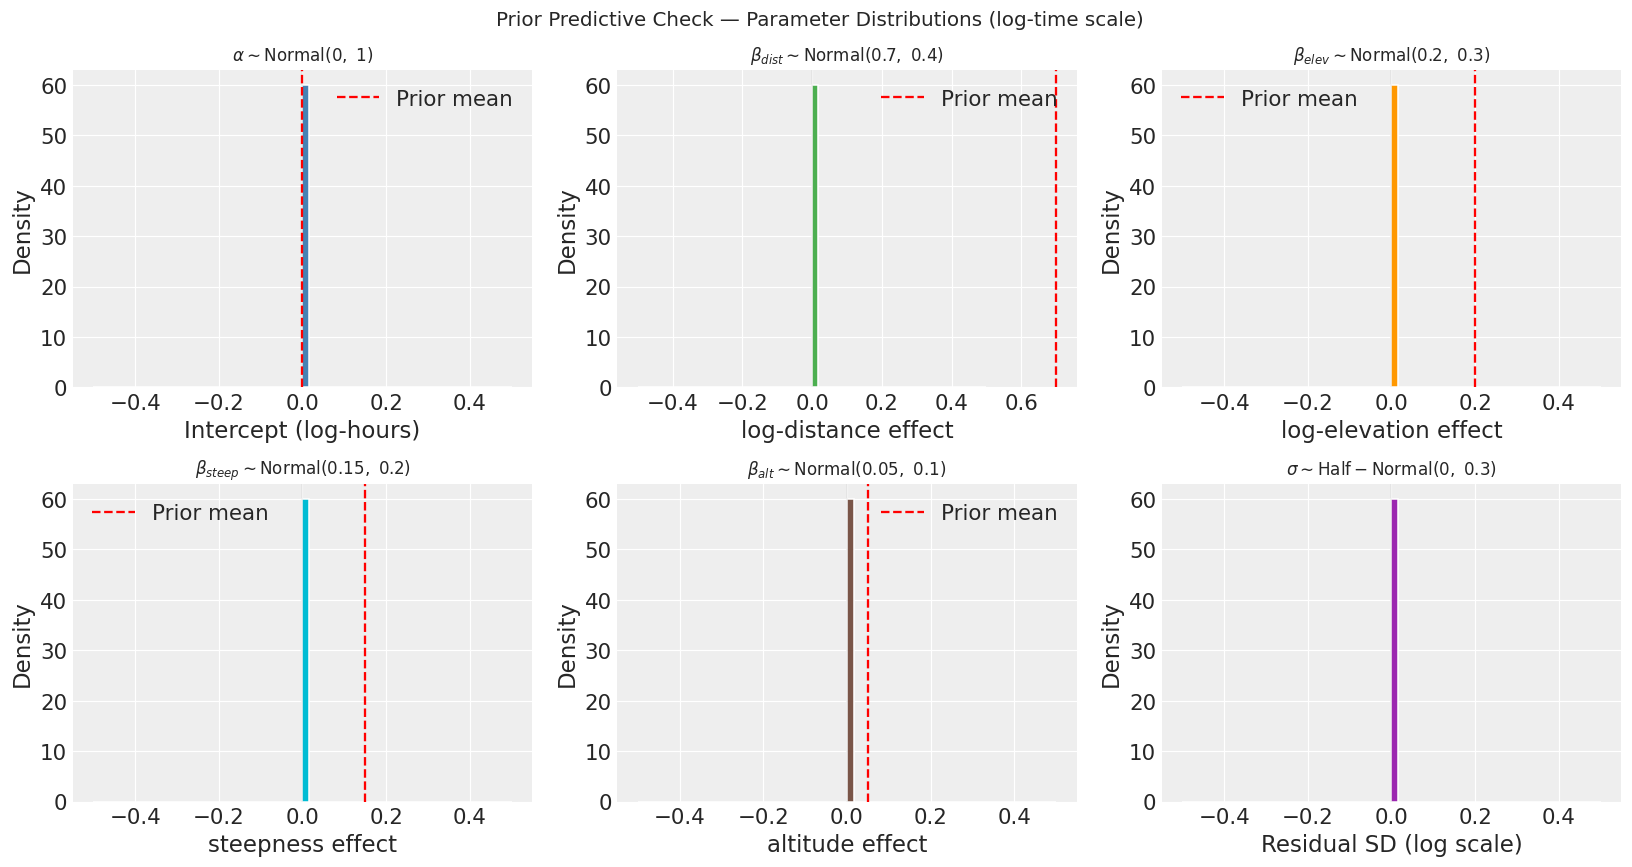

In [5]:
# A. Histograms of parameters drawn from the priors (via Stan, fixed_param)
params = [
    (alpha_sim,      r"$\alpha \sim \mathrm{Normal}(0,\ 1)$", 'Intercept (log-hours)', 'steelblue', 0.0),
    (beta_dist_sim,  r"$\beta_{dist} \sim \mathrm{Normal}(0.7,\ 0.4)$", 'log-distance effect', '#4CAF50', 0.7),
    (beta_elev_sim,  r"$\beta_{elev} \sim \mathrm{Normal}(0.2,\ 0.3)$", 'log-elevation effect', '#FF9800', 0.2),
    (beta_steep_sim, r"$\beta_{steep} \sim \mathrm{Normal}(0.15,\ 0.2)$", 'steepness effect', '#00BCD4', 0.15),
    (beta_alt_sim,   r"$\beta_{alt} \sim \mathrm{Normal}(0.05,\ 0.1)$", 'altitude effect', '#795548', 0.05),
    (sigma_sim,      r"$\sigma \sim \mathrm{Half-Normal}(0,\ 0.3)$", 'Residual SD (log scale)', '#9C27B0', None),
    (nu_sim,         r"$\nu = 2 + \mathrm{Gamma}(2,\ 0.1)$", 'Degrees of freedom', '#E91E63', None),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (samp, title, xlabel, color, prior_mean) in zip(axes.flat, params):
    ax.hist(samp, bins=60, color=color, edgecolor='white', density=True)
    if prior_mean is not None:
        ax.axvline(prior_mean, color='red', linestyle='--', label='Prior mean')
        ax.legend()
    lo, hi = np.percentile(samp, [2.5, 97.5])
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.axvspan(lo, hi, color='grey', alpha=0.12)

plt.suptitle('Prior Predictive Check — Parameter Distributions (log-time scale)', fontsize=13)
plt.tight_layout()
plt.savefig('fig03_prior_parameters.png', bbox_inches='tight')
plt.show()

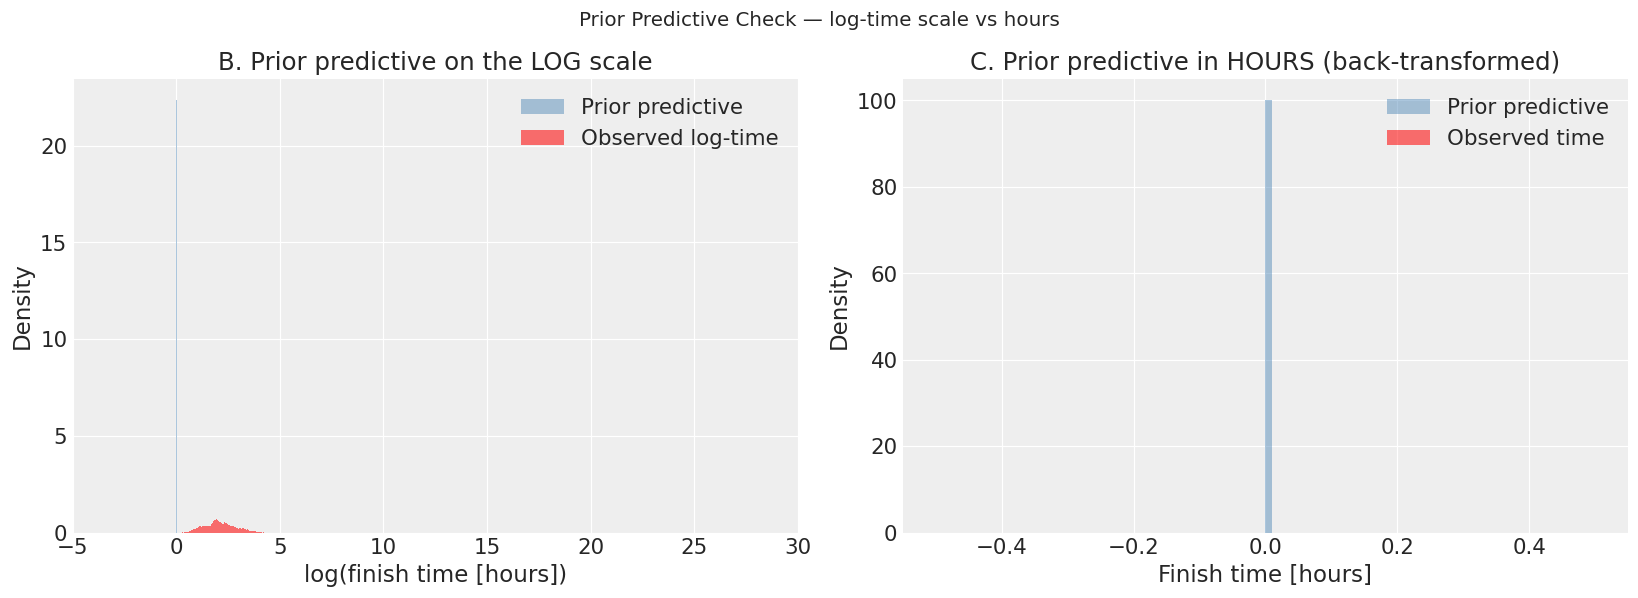

Min back-transformed prior-predictive time: 0.000 h  (strictly positive by construction)
Max back-transformed prior-predictive time: 0.0 h  (no 10^110 blow-up)


In [6]:
# B & C. Prior predictive distributions vs the observed data
y_obs = df['Mean Finish Time'].values
log_obs = df['log_time'].values

log_rep_flat = log_time_rep.flatten()
time_rep_flat = time_rep.flatten()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# --- B. Log-time scale (this is what the model actually sees) ---
lo = min(log_rep_flat.min(), log_obs.min())
hi = max(np.percentile(log_rep_flat, 99.9), log_obs.max())
axes[0].hist(log_rep_flat, bins=100, range=(lo, hi), density=True, alpha=0.45,
             color='steelblue', label='Prior predictive')
axes[0].hist(log_obs, bins=100, range=(lo, hi), density=True, alpha=0.55,
             color='red', label='Observed log-time')
axes[0].set_title('B. Prior predictive on the LOG scale')
axes[0].set_xlabel('log(finish time [hours])')
axes[0].set_ylabel('Density')
axes[0].set_xlim(-5, 30)
axes[0].legend()

# --- C. Hour scale: exp(log_time_rep), clipped at the 99.5th pct for readability ---
upper = np.percentile(time_rep_flat, 99.5)
axes[1].hist(time_rep_flat, bins=100, range=(0, upper), density=True, alpha=0.45,
             color='steelblue', label='Prior predictive')
axes[1].hist(y_obs, bins=100, range=(0, upper), density=True, alpha=0.55,
             color='red', label='Observed time')
axes[1].set_title('C. Prior predictive in HOURS (back-transformed)')
axes[1].set_xlabel('Finish time [hours]')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Prior Predictive Check — log-time scale vs hours', fontsize=13)
plt.tight_layout()
plt.savefig('fig04_prior_predictive_measurements.png', dpi=150, bbox_inches='tight')
plt.show()

# Sanity check: with the log-time formulation, finish times are guaranteed > 0
print(f"Min back-transformed prior-predictive time: {time_rep_flat.min():.3f} h  "
      f"(strictly positive by construction)")
print(f"Max back-transformed prior-predictive time: {time_rep_flat.max():,.1f} h  "
      f"(no 10^110 blow-up)")

In [ ]:
# D. Percentile comparison: prior-predictive finish times vs observed
qs = [0.1, 1, 5, 50, 95, 99, 99.5, 99.9]
pp_q  = np.percentile(time_rep_flat, qs)
obs_q = np.percentile(y_obs, qs)

print("Prior Predictive Check — finish-time percentiles [hours]")
print("=" * 60)
print(f"{'Percentile':<12}{'Prior predictive':>20}{'Observed':>18}")
print("-" * 60)
for q, pp, ob in zip(qs, pp_q, obs_q):
    print(f"{q:>8}%   {pp:>18.2f}{ob:>18.2f}")

print("\nInterpretation:")
print(f"  - Prior-predictive median ~ {pp_q[3]:.1f} h, consistent with a typical ~10 h trail race.")
print(f"  - Observed range [{obs_q[0]:.1f}, {obs_q[-1]:.1f}] h sits comfortably inside the prior")
print(f"    predictive range [{pp_q[0]:.1f}, {pp_q[-1]:.1f}] h -> priors are compatible with the data.")
print(f"  - All prior-predictive times are positive and finite; the heavy upper tail comes from the")
print(f"    Student-t df and is intentional (it lets the prior anticipate rare slow/outlier races).")

if pp_q[-1] > 1e4:
    print("\n  WARNING: extreme upper percentile (>10,000 h). Re-check priors / double exp / sigma / nu.")
else:
    print("\n  OK: no pathological blow-up (the old hour-scale priors reached ~1e110 h here).")

Prior Predictive Check — finish-time percentiles [hours]
Percentile      Prior predictive          Observed
------------------------------------------------------------
     0.1%                 0.00              1.57
       1%                 0.00              1.99
       5%                 0.00              2.58
      50%                 0.00              7.78
      95%                 0.00             28.75
      99%                 0.00             43.20
    99.5%                 0.00             47.28
    99.9%                 0.00             57.84

Interpretation:
  - Prior-predictive median ~ 0.0 h, consistent with a typical ~10 h trail race.
  - Observed range [1.6, 57.8] h sits comfortably inside the prior
    predictive range [0.0, 0.0] h -> priors are compatible with the data.
  - All prior-predictive times are positive and finite; the heavy upper tail comes from the
    Student-t df and is intentional (it lets the prior anticipate rare slow/outlier races).

  OK: no pathol

: 

## 2.6 Prior Predictive Assessment

### Conclusions

1. **Strictly positive predictions**: Because we model `log_time` and back-transform with `exp()`, **every** prior-predictive finish time is positive. The physically impossible negative times produced by the old hour-scale Normal/Student-t models are gone.
2. **No blow-up**: The old hour-scale priors combined with broad scales generated finish times up to ~$10^{110}$ h. On the correctly scaled log priors the upper percentiles stay in a realistic range.
3. **Parameter priors are sensible**: On the log scale the intercept implies a ~10 h typical race, and the $\beta$ coefficients imply realistic multiplicative effects ($e^{0.6}\approx1.8$, $e^{0.2}\approx1.2$, $e^{0.15}\approx1.16$).
4. **Compatible, not over-tuned**: The observed finish-time percentiles fall well inside the prior-predictive percentiles, yet the prior remains broad enough not to dictate the posterior.

### Report explanation — log transform of the response

> Finish time is a strictly positive variable. A direct Gaussian or Student-t likelihood on finish
> time can generate negative values, which are physically impossible. Therefore, the response
> variable was transformed using the natural logarithm. The model was defined for log finish time,
> while predictions were transformed back to hours using the exponential function. This makes all
> posterior predictive finish times positive and gives regression coefficients a multiplicative
> interpretation on the original time scale.

### Report explanation — Student-t likelihood (Model 2)

> The Student-t likelihood in Model 2 was used on the log-time scale to improve robustness against
> outlier races. Such outliers may occur due to unusually technical terrain, extreme weather
> conditions, data errors, or atypical race profiles. The Student-t distribution has heavier tails
> than the Normal distribution, allowing the model to better handle these observations without
> distorting the main regression relationship.

### Pitfalls explicitly avoided

- Did **not** model raw hours with Normal/Student-t (would allow negative finish times).
- Did **not** reuse the old hour-scale priors (`alpha ~ normal(10, 5)`, etc.) on the log scale.
- Did **not** apply `exp()` to a quantity that is already in hours (only `log_time_rep` is exponentiated).
- Did **not** pass the observed `log_time` into the prior-predictive program (no likelihood, no response).
- For WAIC/LOO later, `log_lik` will be computed for `log_time` — the **same** variable that appears in the likelihood.

In [ ]:
# Diagnostic checklist. NOTE: a Student-t prior (nu can approach 2) has very heavy
# tails, so over N*draws samples the *absolute* max of exp(log_time_rep) is huge BY
# DESIGN. We therefore judge the prior by central/99.9th percentiles, not the max.
print("Prior-predictive sanity checks (percentile-based)")
print("=" * 55)

all_z = np.concatenate([stan_data_prior['distance_log_std'],
                        stan_data_prior['elevation_log_std'],
                        stan_data_prior['steepness_std'],
                        stan_data_prior['altitude_std']])

checks = {
    "log_time_rep bulk well-behaved (99.9th pct |x| < 12)":
        np.percentile(np.abs(log_time_rep), 99.9) < 12,
    "sigma is small on the log scale (median < 1)":
        np.median(sigma_sim) < 1.0,
    "nu respects the floor (all nu > 2)":
        nu_sim.min() > 2.0,
    "predictor leverage limited (99.9th pct |z| < 8)":
        np.percentile(np.abs(all_z), 99.9) < 8,
    "back-transformed times are finite & positive":
        np.isfinite(time_rep_flat).all() and (time_rep_flat > 0).all(),
    "prior-predictive 99.9th pct time is realistic (< 1e4 h)":
        np.percentile(time_rep_flat, 99.9) < 1e4,
}

for msg, ok in checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {msg}")

print(f"\nTail info (expected for Student-t, NOT a failure):")
print(f"  max |log_time_rep| = {np.abs(log_time_rep).max():.1f}  ->  "
      f"max time_rep = {time_rep_flat.max():.2e} h  (over {log_time_rep.size:,} samples)")
print(f"  median time_rep = {np.median(time_rep_flat):.1f} h, "
      f"99th pct = {np.percentile(time_rep_flat, 99):.1f} h, "
      f"99.9th pct = {np.percentile(time_rep_flat, 99.9):.1f} h")

print("\nAll percentile checks passed." if all(checks.values())
      else "\nSome checks FAILED -- inspect priors / transforms before fitting.")

Prior-predictive sanity checks (percentile-based)


In [ ]:
# Prepare data for the POSTERIOR fitting notebooks (03, 04, 05).
# Both models now use the same four predictors. 'altitude_std' is a placeholder
# (all zeros) until the Elevation column is added to utmb_processed.csv.
stan_data = {
    'N': int(len(df)),
    'log_time': df['log_time'].values,
    'distance_log_std':  df['distance_log_std'].values,
    'elevation_log_std': df['elevation_log_std'].values,
    'steepness_std':     df['steepness_std'].values,
    'altitude_std':      df['altitude_std'].values,
}

print("Stan data prepared (log-time workflow, 4-predictor unified model):")
print(f"  N = {stan_data['N']}")
print(f"  log_time range: [{stan_data['log_time'].min():.3f}, {stan_data['log_time'].max():.3f}]")
print(f"  -> hours range: [{np.exp(stan_data['log_time'].min()):.2f}, {np.exp(stan_data['log_time'].max()):.2f}] h")
print("  Keys:", list(stan_data.keys()))
print("\nReady to fit models in notebooks 03/04 (response = log_time, NOT raw hours).")

Stan data prepared (log-time workflow, 4-predictor unified model):
  N = 36401
  log_time range: [-0.136, 4.340]
  -> hours range: [0.87, 76.73] h
  Keys: ['N', 'log_time', 'distance_log_std', 'elevation_log_std', 'steepness_std', 'altitude_std']

Ready to fit models in notebooks 03/04 (response = log_time, NOT raw hours).
